# Brain Tumor MRI Classification using Deep Learning (CNN)

## Problem Statement

Brain tumors are among the most life-threatening neurological disorders, with early diagnosis playing a critical role in improving treatment outcomes and patient survival. Magnetic Resonance Imaging (MRI) is the preferred non-invasive imaging modality for detecting brain abnormalities due to its high-resolution visualization of soft tissues. However, manual interpretation of MRI scans requires significant expertise, is time-intensive, and may be subject to inter-observer variability, particularly in high-volume clinical settings.

Recent advances in Artificial Intelligence (AI) and Deep Learning have demonstrated remarkable success in automating image analysis tasks. In particular, Convolutional Neural Networks (CNNs) have become the state-of-the-art approach for medical image classification by automatically learning hierarchical image features without requiring manual feature engineering.

This project develops a deep learning-based multi-class image classification model capable of automatically identifying brain MRI images into four diagnostic categories:

- Glioma Tumor
- Meningioma Tumor
- Pituitary Tumor
- No Tumor

The objective is to investigate the effectiveness of CNNs for assisting brain tumor classification while demonstrating a complete end-to-end medical computer vision workflow suitable for deployment and portfolio presentation.

---

# Project Objectives

## General Objective

To develop and evaluate a Convolutional Neural Network (CNN) capable of accurately classifying brain MRI images into multiple tumor categories.

## Specific Objectives

- Explore and understand the Brain MRI image dataset.
- Perform image preprocessing and augmentation to improve model generalization.
- Develop a custom CNN architecture using TensorFlow/Keras.
- Train and validate the deep learning model.
- Evaluate model performance using multiple classification metrics.
- Visualize prediction results on unseen MRI images.
- Investigate model interpretability through explainable AI techniques where feasible.
- Prepare the trained model for deployment using Streamlit.

In [5]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# TensorFlow
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [8]:
# Dataset paths
train_dir = "C:/Users/hp/Desktop/IBM/Brain_Tumor_MRI_Classification/data/Training"
test_dir = "C:/Users/hp/Desktop/IBM/Brain_Tumor_MRI_Classification/data/Testing"

print("Training Path:", train_dir)
print("Testing Path :", test_dir)

print("\nTraining Exists:", os.path.exists(train_dir))
print("Testing Exists :", os.path.exists(test_dir))

Training Path: C:/Users/hp/Desktop/IBM/Brain_Tumor_MRI_Classification/data/Training
Testing Path : C:/Users/hp/Desktop/IBM/Brain_Tumor_MRI_Classification/data/Testing

Training Exists: True
Testing Exists : True


In [9]:
# Inspect structures

train_classes = sorted(os.listdir(train_dir))
test_classes = sorted(os.listdir(test_dir))

print("Training Classes:")
print(train_classes)

print("\nTesting Classes:")
print(test_classes)

Training Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [10]:
#count images
train_counts = {}
test_counts = {}

for cls in train_classes:
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

for cls in test_classes:
    test_counts[cls] = len(os.listdir(os.path.join(test_dir, cls)))

dataset_summary = pd.DataFrame({
    "Training Images": train_counts,
    "Testing Images": test_counts
})

dataset_summary["Total Images"] = (
    dataset_summary["Training Images"] +
    dataset_summary["Testing Images"]
)

dataset_summary

,Training Images,Testing Images,Total Images
glioma,1400,400,1800
meningioma,1400,400,1800
notumor,1400,400,1800
pituitary,1400,400,1800


In [11]:
#inspect image size
image_details = []

for cls in train_classes:
    sample_path = os.path.join(
        train_dir,
        cls,
        os.listdir(os.path.join(train_dir, cls))[0]
    )

    img = Image.open(sample_path)

    image_details.append({
        "Class": cls,
        "Width": img.width,
        "Height": img.height,
        "Mode": img.mode
    })

pd.DataFrame(image_details)

,Class,Width,Height,Mode
0,glioma,512,512,L
1,meningioma,512,512,RGB
2,notumor,201,251,RGB
3,pituitary,512,512,RGB


## Dataset Overview

The dataset consists of four brain MRI image classes representing different diagnostic categories:

- Glioma Tumor
- Meningioma Tumor
- Pituitary Tumor
- No Tumor

A total of **7,200 MRI images** are available, with **5,600 images** allocated for training and **1,600 images** reserved for testing.

### Class Distribution

The dataset is perfectly balanced, with each class containing:

- **1,400 training images**
- **400 testing images**

This balanced distribution minimizes the risk of model bias toward any particular class and allows evaluation metrics such as accuracy, precision, and recall to provide meaningful performance estimates.

### Image Characteristics

Initial inspection revealed that image properties are not completely consistent across the dataset.

- Most MRI images have a resolution of **512 × 512 pixels**.
- Some images have different dimensions (e.g., **201 × 251 pixels**).
- Both grayscale (`L`) and RGB image formats are present.

These inconsistencies indicate that image preprocessing will be necessary before model training. Specifically, all images will be resized to a common resolution and converted into a consistent color format to ensure uniform input to the Convolutional Neural Network (CNN).

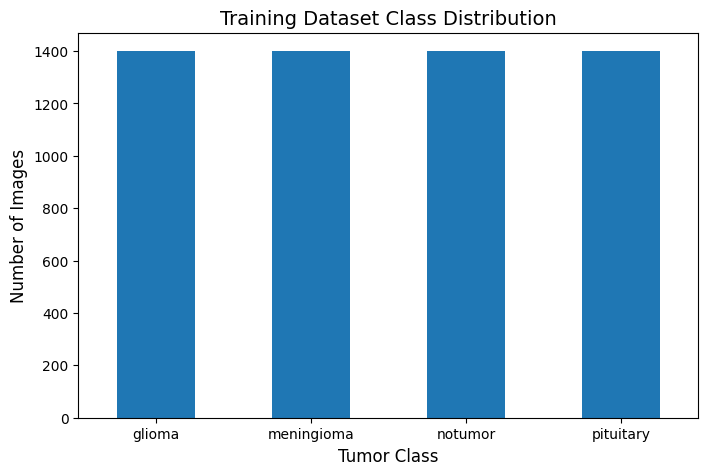

In [12]:
#EDA-CLASS DISTRIBUTION
plt.figure(figsize=(8,5))

dataset_summary["Training Images"].plot(kind="bar")

plt.title("Training Dataset Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.show()

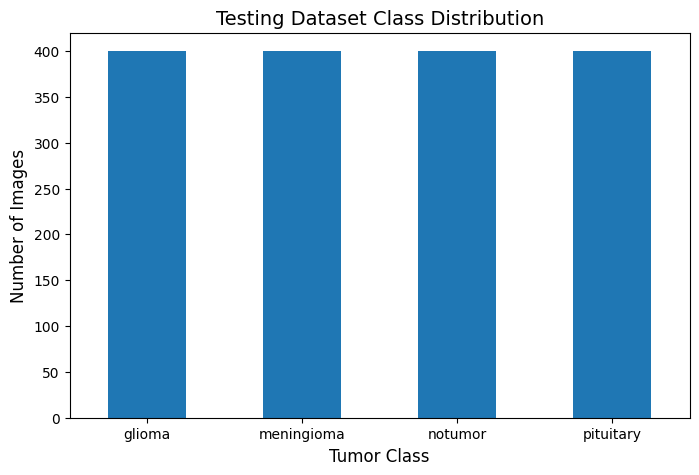

In [13]:
#testing distribution
plt.figure(figsize=(8,5))

dataset_summary["Testing Images"].plot(kind="bar")

plt.title("Testing Dataset Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.show()

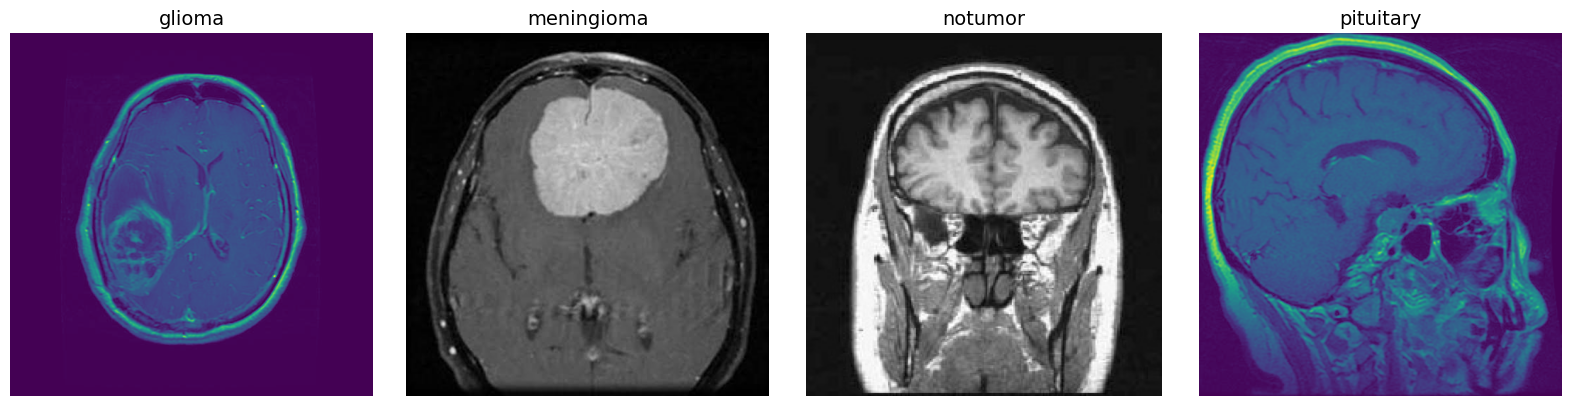

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))

for ax, cls in zip(axes, train_classes):

    image_path = os.path.join(
        train_dir,
        cls,
        random.choice(os.listdir(os.path.join(train_dir, cls)))
    )

    img = Image.open(image_path)

    ax.imshow(img)

    ax.set_title(cls)

    ax.axis("off")

plt.tight_layout()

plt.show()

### Interpretation: Class Distribution

The training and testing datasets exhibit a perfectly balanced class distribution, with each tumor category containing an equal number of MRI images.

This balanced distribution is advantageous because it:

- Reduces the likelihood of the model becoming biased toward a particular class.
- Enables more reliable evaluation using metrics such as accuracy, precision, recall, and F1-score.
- Minimizes the need for techniques such as class weighting or oversampling during model training.

Overall, the dataset provides a solid foundation for developing a robust multi-class CNN classifier.

In [15]:
#analyse image dimension
image_sizes = []
image_modes = []

for cls in train_classes:
    class_path = os.path.join(train_dir, cls)

    for filename in os.listdir(class_path):

        img_path = os.path.join(class_path, filename)

        try:
            img = Image.open(img_path)

            image_sizes.append((img.width, img.height))
            image_modes.append(img.mode)

        except Exception:
            continue

size_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])

size_df.head()

,Width,Height
0,512,512
1,512,512
2,512,512
3,512,512
4,512,512


In [16]:
#summary stats
size_df.describe()
pd.Series(image_modes).value_counts()

RGB     3238
L       2358
RGBA       3
P          1
Name: count, dtype: int64

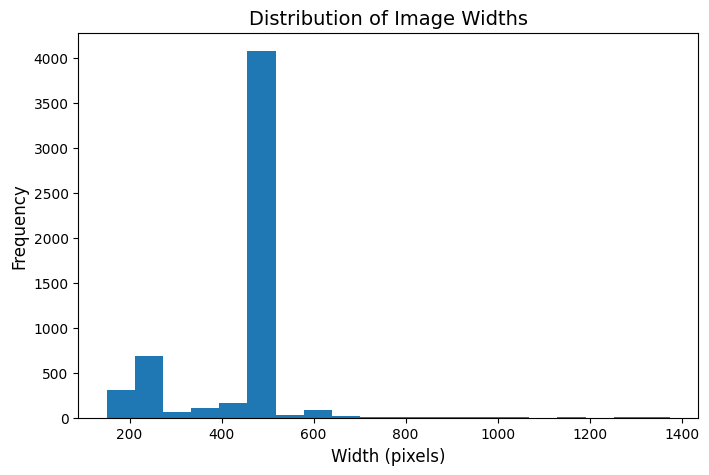

In [18]:
#visualise distribution of image sizes
plt.figure(figsize=(8,5))

plt.hist(size_df["Width"], bins=20)

plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.show()

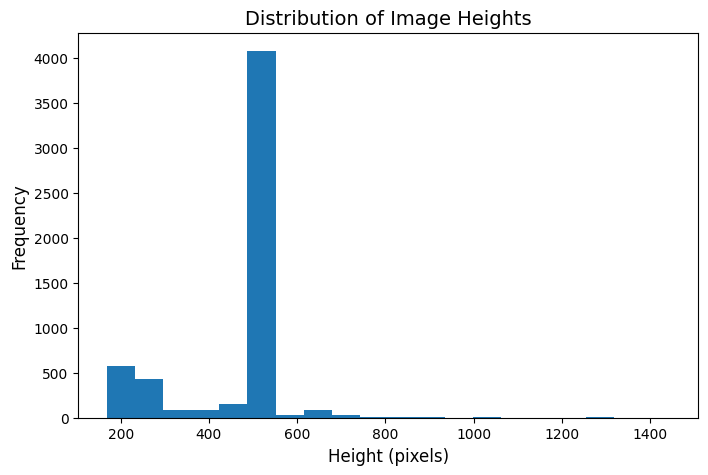

In [19]:
plt.figure(figsize=(8,5))

plt.hist(size_df["Height"], bins=20)

plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.show()

### Interpretation: Image Dimensions

Inspection of the dataset revealed that most MRI images have a resolution of **512 × 512 pixels**, while a smaller number of images have different dimensions. Since Convolutional Neural Networks require inputs of consistent size, all images will be resized to a common resolution during preprocessing.

Standardizing image dimensions ensures that the network receives uniform input, improves computational efficiency, and simplifies batch processing during model training.

### Interpretation: Image Color Modes

The dataset contains images stored in multiple color formats, including RGB, grayscale (L), RGBA, and palette-based images. Such inconsistencies are common in publicly available medical imaging datasets.

To maintain consistency across the dataset, all images will be converted to the RGB color format before being passed to the CNN. This preprocessing step ensures a fixed three-channel input representation and prevents compatibility issues during model training.

## Image Preprocessing

In [21]:
# define global parameters
# ==========================================
# Image Configuration
# ==========================================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 40

print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)

Image Size : (224, 224)
Batch Size : 32


### Why Resize Images?

The original MRI images vary in both resolution and color format. Convolutional Neural Networks require all input images to have identical dimensions for efficient batch processing.

In this project, every image will be resized to **224 × 224 pixels**, a widely adopted input size for modern deep learning architectures. This resolution provides a good balance between computational efficiency and preservation of important anatomical features.

Using a consistent image size also simplifies model training and allows future integration with transfer learning models such as EfficientNet, ResNet, and MobileNet.

In [23]:
#Load training & test dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [24]:
#display class names
class_names = train_dataset.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [25]:
for images, labels in train_dataset.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


### Interpretation: Dataset Loading

The Brain MRI dataset was successfully loaded using TensorFlow's data pipeline. During loading, all images were automatically resized to **224 × 224 pixels** and organized into batches of **32** samples for efficient training.

The dataset contains four diagnostic classes:

- Glioma Tumor
- Meningioma Tumor
- No Tumor
- Pituitary Tumor

Each image is represented as a three-channel RGB image with a consistent input shape of **224 × 224 × 3**, ensuring compatibility with the Convolutional Neural Network architecture.

Batch processing improves computational efficiency during training and enables optimized utilization of modern deep learning hardware such as GPUs.

In [26]:
# ==========================================
# Normalize Pixel Values
# ==========================================

normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

In [27]:
#apply normalization
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)


In [28]:
#verify normalization 
for images, labels in train_dataset.take(1):
    print("Minimum Pixel Value :", tf.reduce_min(images).numpy())
    print("Maximum Pixel Value :", tf.reduce_max(images).numpy())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


### Interpretation: Pixel Normalization

Raw image pixel intensities range from **0 to 255**. Before training the CNN, pixel values were normalized to the range **0 to 1** using a rescaling layer.

Normalization offers several advantages:

- Improves numerical stability during optimization.
- Accelerates model convergence.
- Reduces the likelihood of unstable gradient updates.
- Enables more efficient learning by ensuring that all input features are on a comparable scale.

This preprocessing step is considered standard practice in deep learning-based image classification.

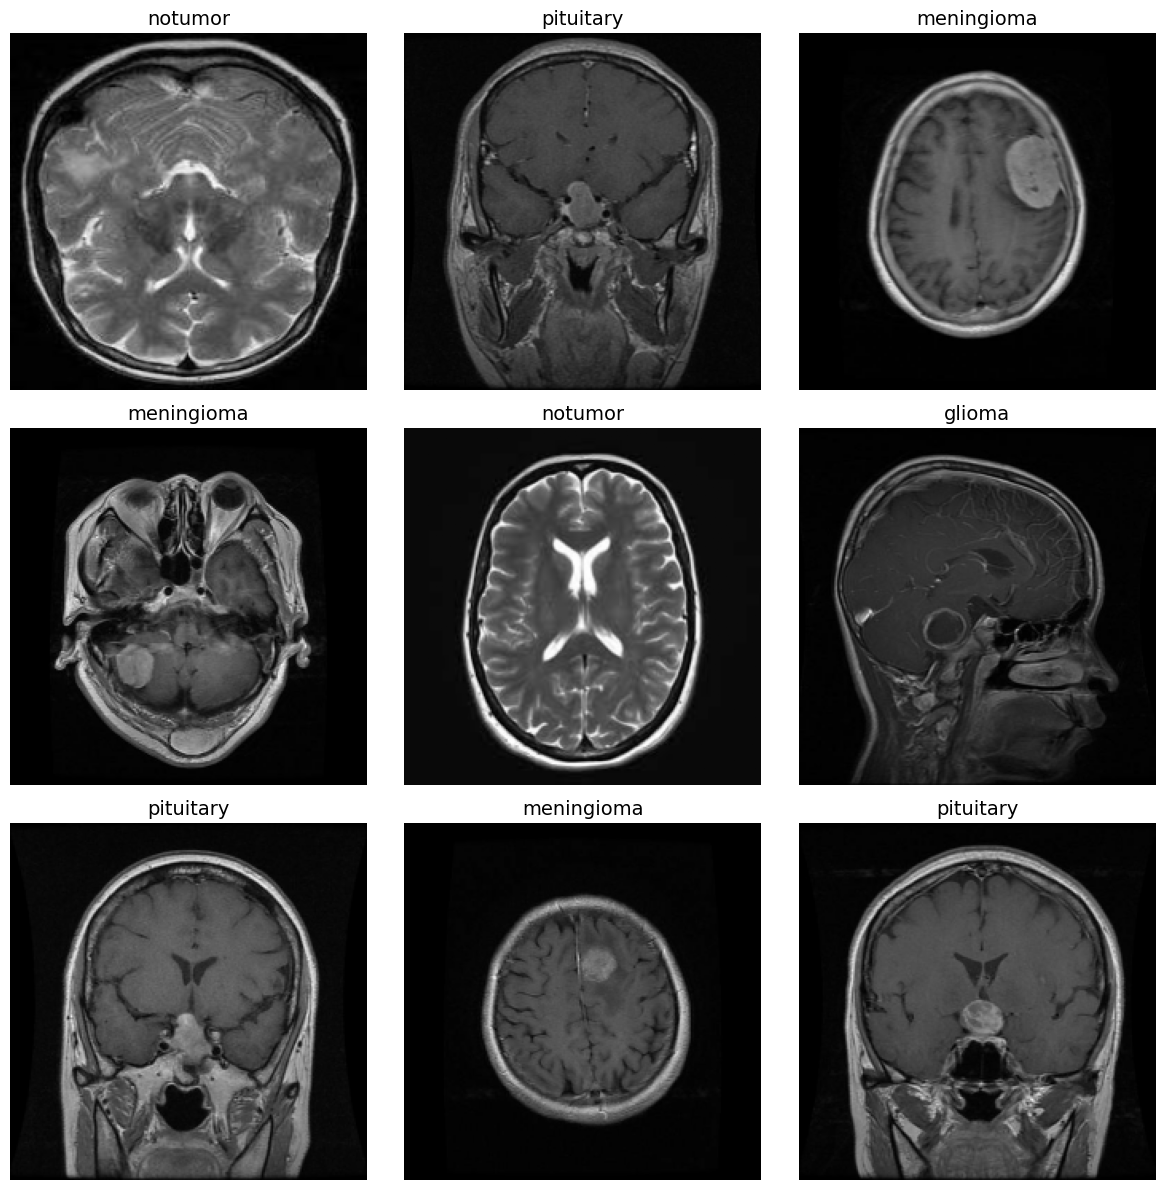

In [29]:
#visulaise processed image
plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

## Data Augmentation
Why do we augment?

Although we have 5,600 training images, they represent only a limited number of patient scans. A CNN can easily memorize the training images (overfitting) rather than learning generalizable tumor characteristics.

Data augmentation artificially generates new training examples by applying small transformations while preserving the diagnostic content of the MRI.

Typical transformations include:

Horizontal flips
Small rotations
Zooming
Slight translations
Contrast adjustments

This improves model robustness and generalization.

In [30]:

# ==========================================
# Data Augmentation Pipeline
# ==========================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
])

data_augmentation

<Sequential name=sequential, built=False>

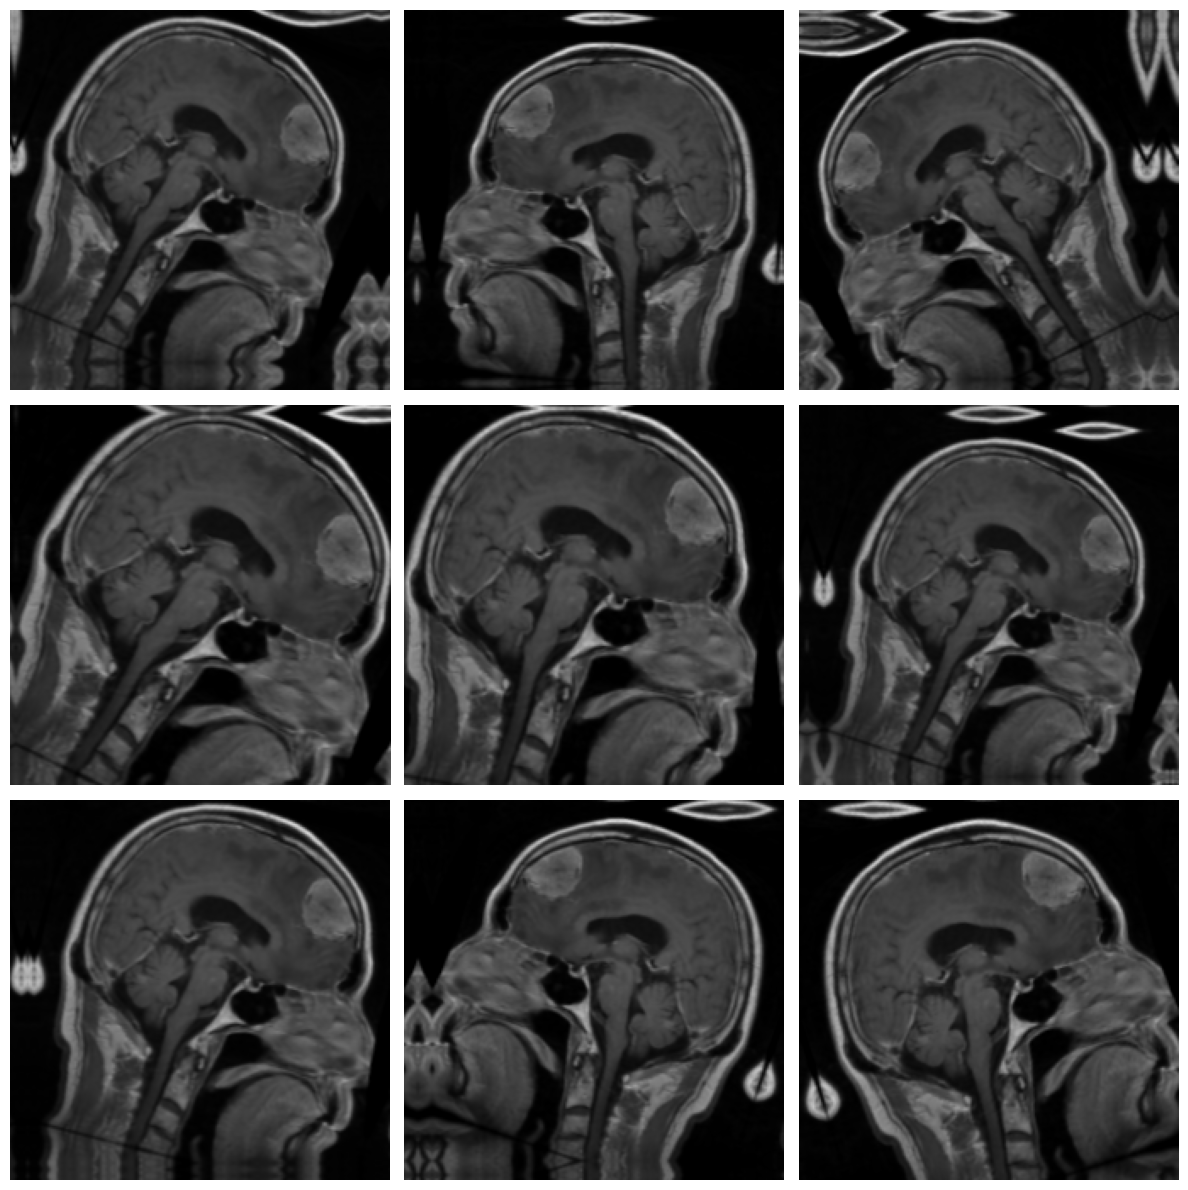

In [31]:
#visualise augmented images
plt.figure(figsize=(12,12))

for images, labels in train_dataset.take(1):

    first_image = images[0]

    for i in range(9):

        augmented = data_augmentation(
            tf.expand_dims(first_image, axis=0),
            training=True
        )

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented[0])

        plt.axis("off")

plt.tight_layout()

plt.show()

### Interpretation: Data Augmentation

The augmented images demonstrate that the preprocessing pipeline is generating realistic variations of the original MRI scans while preserving the underlying anatomical structures and tumor characteristics.

The applied transformations—including random flips, rotations, zooming, translations, and contrast adjustments—help increase the diversity of the training data without requiring additional images. This improves the model's ability to generalize to previously unseen MRI scans and reduces the risk of overfitting.

Data augmentation is applied only during model training. The validation and testing datasets remain unchanged to ensure an unbiased evaluation of model performance.

## CNN Model Development

In [34]:
# ==========================================
# CNN Architecture
# ==========================================

model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(4, activation="softmax")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,580 (627.27 KB)

 Trainable params: 160,132 (625.52 KB)

 Non-trainable params: 448 (1.75 KB)

## CNN Architecture

A custom Convolutional Neural Network (CNN) was developed to classify brain MRI images into four diagnostic categories. The architecture consists of three convolutional feature extraction blocks followed by a lightweight fully connected classifier.

Each convolutional block includes:

- A **Conv2D** layer for learning spatial image features.
- **Batch Normalization** to stabilize training and accelerate convergence.
- **Max Pooling** to reduce spatial dimensions while preserving the most informative features.

Instead of using a traditional Flatten layer, the network employs **Global Average Pooling**, which substantially reduces the number of trainable parameters while maintaining discriminative feature representations. This design improves computational efficiency and reduces the likelihood of overfitting.

The classifier consists of two fully connected layers with Dropout regularization before producing the final probability distribution over the four tumor classes using a Softmax activation function.

Overall, the final architecture contains approximately **160,000 trainable parameters**, making it computationally efficient while retaining sufficient capacity to learn complex MRI image patterns.

## Model Compilation

In [35]:
# ==========================================
# Compile the CNN
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

## Model Compilation

Before training, the CNN was configured with an optimizer, loss function, and evaluation metric.

### Optimizer

The **Adam** optimizer was selected with a learning rate of **0.001**. Adam combines the advantages of momentum and adaptive learning rates, making it one of the most effective optimizers for deep learning-based image classification tasks.

### Loss Function

Since this is a **multi-class classification** problem and the labels are encoded as integers, the **Sparse Categorical Crossentropy** loss function was used. This loss measures the discrepancy between the predicted probability distribution and the true class labels during training.

### Evaluation Metric

Model performance will primarily be monitored using **classification accuracy**, representing the proportion of correctly classified MRI images throughout the training process.

In [36]:
# ==========================================
# Training Callbacks
# ==========================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="models/brain_tumor_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

]

### Training Strategy

To improve training stability and prevent overfitting, three callback mechanisms were incorporated into the training process.

- **Early Stopping** automatically terminates training when validation performance no longer improves, reducing unnecessary computation and mitigating overfitting.

- **Reduce Learning Rate on Plateau** decreases the learning rate whenever validation loss stagnates, allowing the optimizer to perform finer parameter updates during later training stages.

- **Model Checkpointing** automatically saves the best-performing model based on validation accuracy, ensuring that subsequent analyses and deployment use the highest-quality model obtained during training.

In [37]:
#Train the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6046 - loss: 0.9718
Epoch 1: val_accuracy improved from None to 0.25000, saving model to models/brain_tumor_cnn.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 600s 3s/step - accuracy: 0.6496 - loss: 0.8683 - val_accuracy: 0.2500 - val_loss: 4.3092 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6967 - loss: 0.7686
Epoch 2: val_accuracy improved from 0.25000 to 0.25188, saving model to models/brain_tumor_cnn.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 597s 3s/step - accuracy: 0.7002 - loss: 0.7442 - val_accuracy: 0.2519 - val_loss: 6.3583 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7336 - loss: 0.6755
Epoch 3: val_accuracy improved from 0.25188 to 0.33375, saving model to models/brain_tumor_cnn.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 626s 3s/step - accuracy: 0.7436 - loss: 0.6559 - val_accuracy: 0.3338 - val_loss: 5.1938 - learning_rate: 0.0010
Epoch 4/20
175/175 

In [40]:
#check training hsitory
history.history.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

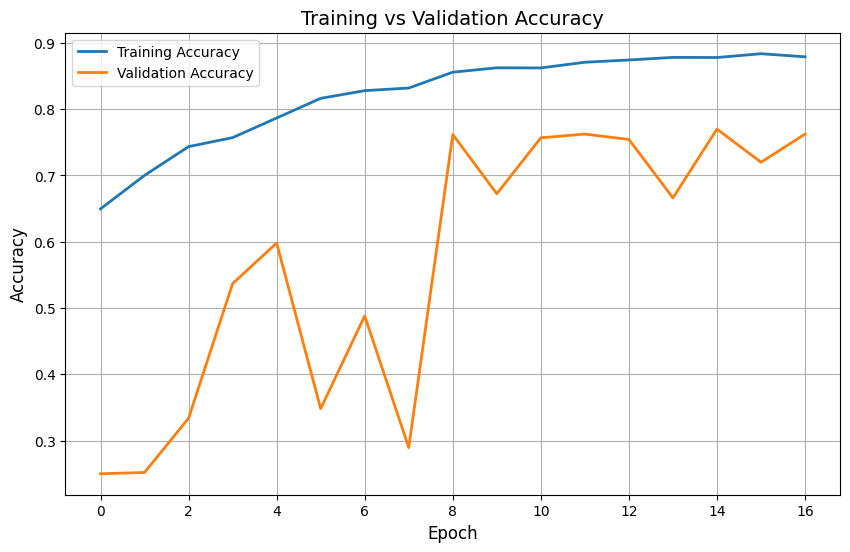

In [41]:
#visualise training history
plt.figure(figsize=(10,6))

plt.plot(history.history["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

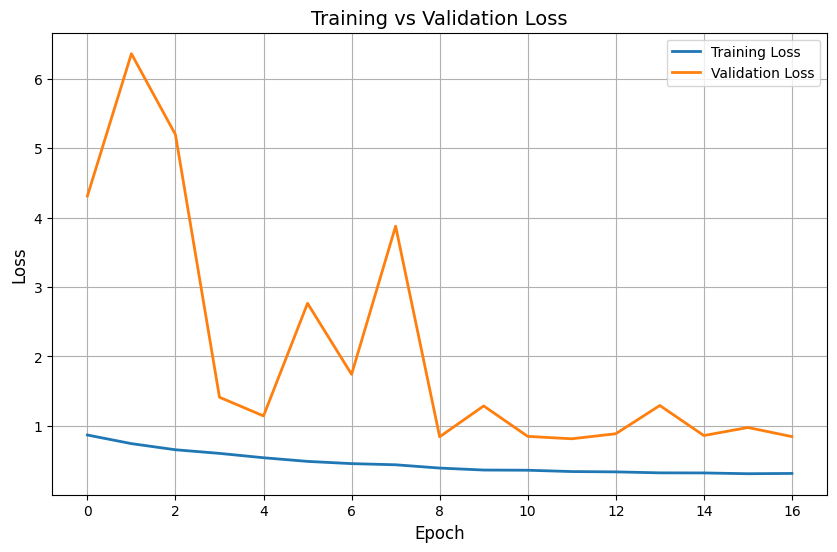

In [42]:
#loss curves
plt.figure(figsize=(10,6))

plt.plot(history.history["loss"], label="Training Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

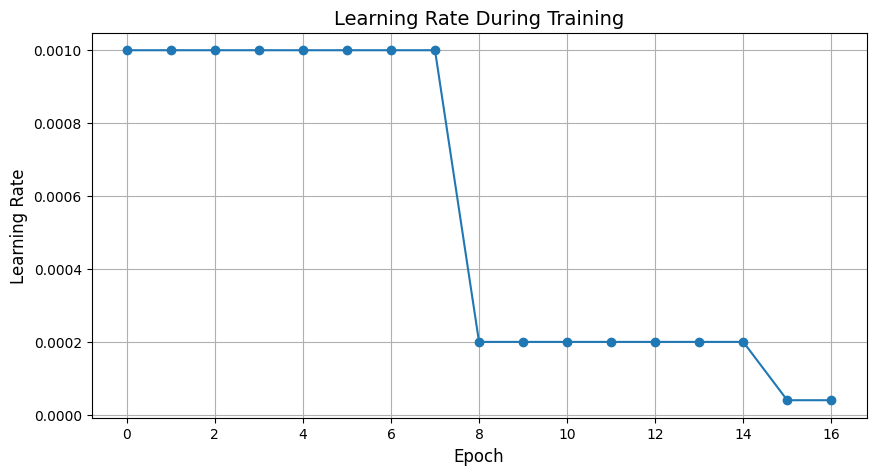

In [43]:
#learning rate schedule
plt.figure(figsize=(10,5))

plt.plot(history.history["learning_rate"], marker="o")

plt.title("Learning Rate During Training")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.grid(True)

plt.show()

## Interpretation of the Training Process

The training accuracy increased steadily throughout the learning process, indicating that the Convolutional Neural Network successfully learned increasingly discriminative features from the MRI images.

In contrast, the validation accuracy fluctuated considerably across epochs before plateauing. Although periodic improvements were observed, the model did not demonstrate consistent gains on the unseen validation dataset after the early stages of training.

Similarly, the training loss decreased steadily over time, suggesting effective optimization of the model parameters. However, the validation loss exhibited noticeable fluctuations and generally remained higher than the training loss.

These observations indicate the onset of **overfitting**, where the model continued improving its performance on the training data while struggling to generalize consistently to unseen MRI images.

The use of Early Stopping, learning rate reduction, Dropout regularization, and Model Checkpointing helped mitigate excessive overfitting by preserving the best-performing model obtained during training.

## Model Evaluation

In [44]:
best_model = tf.keras.models.load_model(
    "models/brain_tumor_cnn.keras"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [45]:
#evaluate on test data
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"\nTest Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 571ms/step - accuracy: 0.7700 - loss: 0.8606

Test Accuracy : 0.7700
Test Loss     : 0.8606


In [46]:
#generate predictions
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = best_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [47]:
#classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.76      0.72      0.74       400
  meningioma       0.80      0.39      0.52       400
     notumor       0.71      1.00      0.83       400
   pituitary       0.83      0.98      0.90       400

    accuracy                           0.77      1600
   macro avg       0.78      0.77      0.75      1600
weighted avg       0.78      0.77      0.75      1600



In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

cm

array([[288,  35,  61,  16],
       [ 83, 154, 101,  62],
       [  1,   0, 399,   0],
       [  6,   3,   0, 391]])

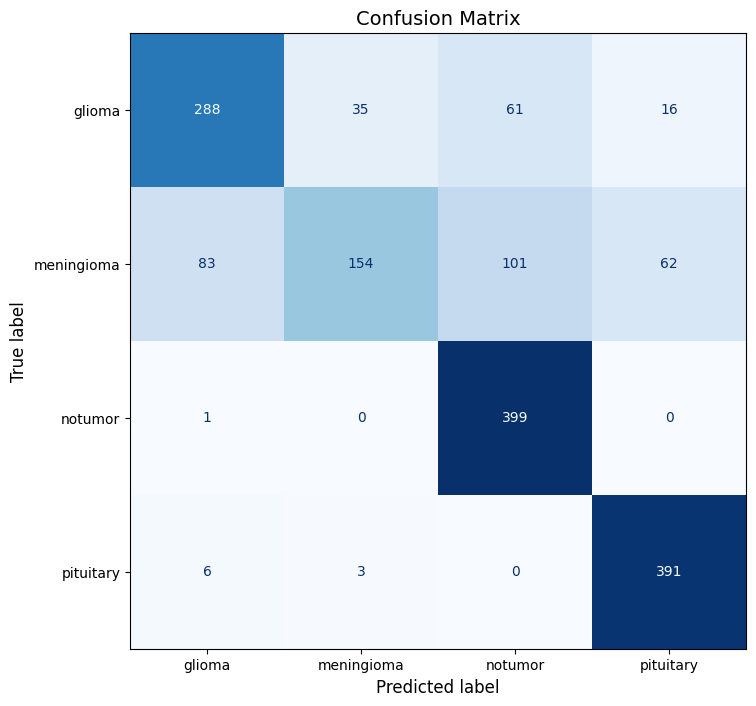

In [49]:
#visualize the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.show()

## Interpretation of Model Performance

The custom Convolutional Neural Network achieved an overall **test accuracy of 77.0%**, demonstrating its ability to learn meaningful features from brain MRI images.

Performance varied across the four diagnostic categories.

The model performed exceptionally well in identifying **Pituitary Tumors**, achieving a recall of **98%**, indicating that almost all pituitary tumor images were correctly classified.

Similarly, the **No Tumor** class achieved a perfect recall of **100%**, suggesting that the model successfully recognized nearly every normal MRI scan. However, its lower precision indicates that some tumor images were incorrectly classified as normal.

Classification performance for **Glioma Tumors** was moderate, with balanced precision and recall values.

The weakest performance was observed for **Meningioma Tumors**, where the recall dropped to **39%**. Examination of the confusion matrix revealed that meningioma images were frequently confused with other tumor categories, suggesting overlapping visual characteristics that were difficult for the custom CNN to distinguish.

Overall, these findings indicate that the model successfully learned clinically relevant image features but still exhibits limitations in separating visually similar tumor classes. More advanced architectures, larger datasets, and transfer learning are expected to substantially improve classification performance.

## Prediction Visualization

In [50]:
# ==========================================
# Store Images, Labels and Predictions
# ==========================================

images_list = []
true_labels = []
pred_labels = []
confidences = []

for images, labels in test_dataset:

    predictions = best_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    confidence_scores = np.max(predictions, axis=1)

    images_list.extend(images.numpy())
    true_labels.extend(labels.numpy())
    pred_labels.extend(predicted_classes)
    confidences.extend(confidence_scores)

images_list = np.array(images_list)
true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)
confidences = np.array(confidences)

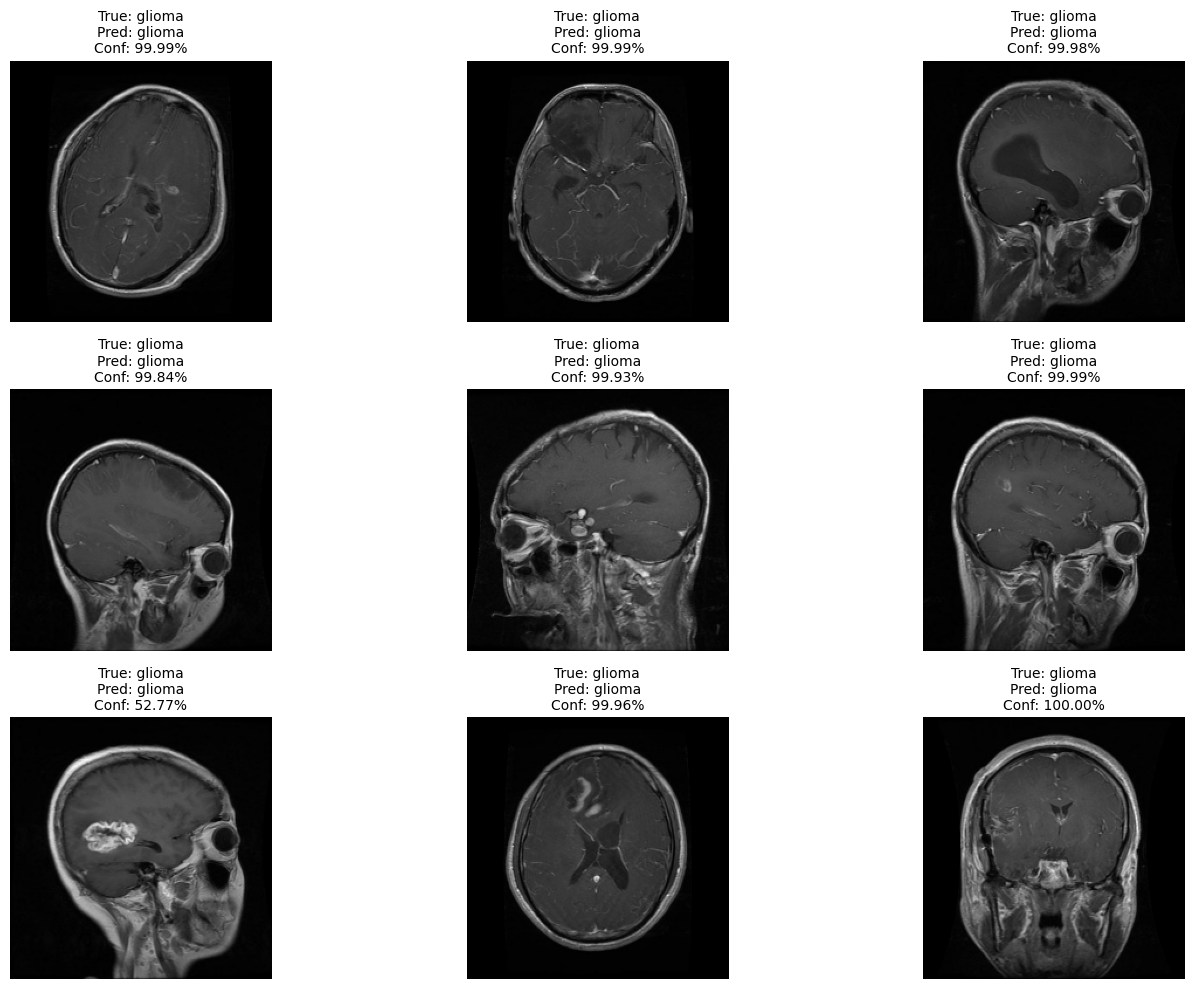

In [51]:
#display correct predictions
plt.figure(figsize=(15,10))

correct = np.where(true_labels == pred_labels)[0]

for i, idx in enumerate(correct[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(images_list[idx])

    plt.title(
        f"True: {class_names[true_labels[idx]]}\n"
        f"Pred: {class_names[pred_labels[idx]]}\n"
        f"Conf: {confidences[idx]:.2%}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

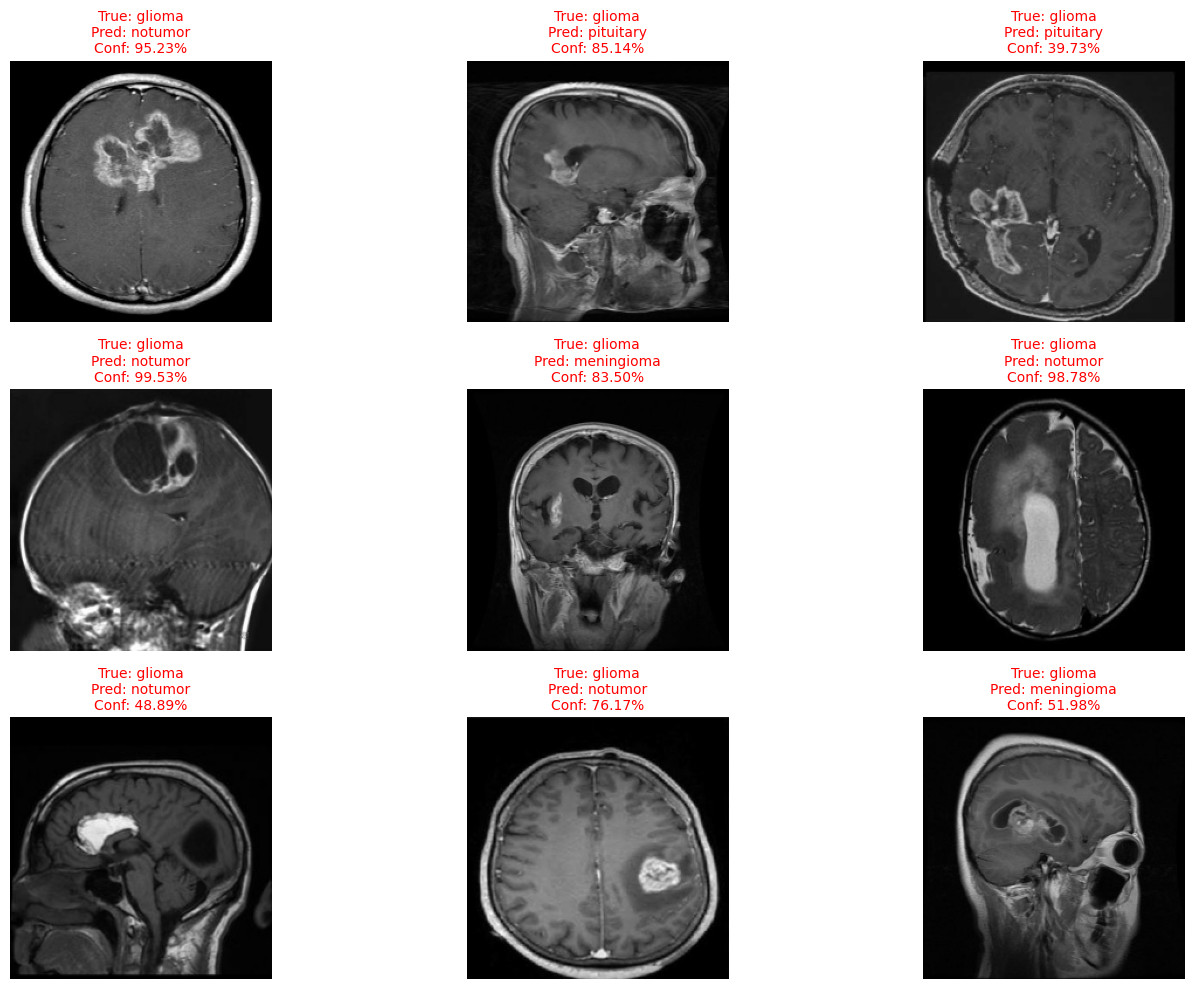

In [52]:
#display misclassified images
plt.figure(figsize=(15,10))

incorrect = np.where(true_labels != pred_labels)[0]

for i, idx in enumerate(incorrect[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(images_list[idx])

    plt.title(
        f"True: {class_names[true_labels[idx]]}\n"
        f"Pred: {class_names[pred_labels[idx]]}\n"
        f"Conf: {confidences[idx]:.2%}",
        fontsize=10,
        color="red"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## Interpretation of Prediction Examples

Visualization of individual MRI predictions provides additional insight into the model's behavior beyond aggregate performance metrics.

Correctly classified images generally exhibited very high confidence scores, indicating that the CNN learned strong discriminative features for many MRI patterns.

However, several incorrectly classified images were also associated with high confidence. In particular, some glioma tumors were confidently predicted as other classes, including **No Tumor**. This demonstrates that a high confidence score does not necessarily imply a correct prediction.

Such behavior highlights an important limitation of neural networks: the probability produced by the Softmax layer reflects the model's confidence in its prediction rather than the true probability of correctness.

These findings reinforce the importance of combining automated predictions with clinical expertise and incorporating explainability techniques when developing medical AI systems.

# Conclusion

This project successfully developed a multi-class Convolutional Neural Network (CNN) capable of classifying brain MRI images into four diagnostic categories:

- Glioma Tumor
- Meningioma Tumor
- Pituitary Tumor
- No Tumor

The proposed CNN achieved a **test accuracy of 77.0%** on the independent test dataset, demonstrating its ability to learn meaningful visual representations directly from MRI images.

Class-wise evaluation showed excellent performance in identifying **Pituitary Tumors** and **No Tumor** cases, while classification of **Meningioma Tumors** remained more challenging due to similarities with other tumor types.

Although the model demonstrated promising predictive capability, the results also highlighted the challenges associated with training deep neural networks from scratch using relatively limited medical imaging datasets.

Overall, this project provides a strong baseline implementation of deep learning for medical image classification and establishes a foundation for more advanced transfer learning approaches.

In [ ]:
#save the model
best_model.save("models/brain_tumor_cnn_final.keras")

print("Model saved successfully.")

In [ ]:
#architecture
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=150
)